# Introduction

**Candidate:** Abderaouf Khelfaoui  
**Assignment Completed For:** MeetMyMama Company  
**Examiner:** Mr. Junned Mohammad  

This document presents my solution to the technical assignment provided by MeetMyMama. The assignment has been approached with careful attention to the problem requirements, ensuring a structured, efficient, and reproducible methodology. Throughout this work, I have applied relevant technical concepts, tools, and best practices to deliver a solution that aligns with the company’s expectations.


## 1. Setup & Data Loading

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load data
df = pd.read_csv('data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1500, 15)


,lead_id,lead_date,event_date,event_day_of_week,event_month,pax,estimated_revenue_eur,delivery_type,zone,lead_source,prestation_type,is_returning_client,is_custom_request,days_lead_to_event,converted
0,1,2023-07-12,2023-10-08,0,10,180,8773.00,Non renseigné,Non renseigné,Site web,Non renseigné,0,0,87,0
1,2,2023-08-07,2023-09-14,4,9,130,9735.00,Non renseigné,Non renseigné,Site web,Offre réception,0,0,37,0
2,3,2024-12-13,2025-02-04,2,2,100,24647.00,Non renseigné,Non renseigné,Email entrant,Offre réception,0,0,52,0
3,4,2025-07-16,2025-09-06,6,9,150,747.18,Livraison,Zone 1,Non renseigné,Cocktail,0,0,51,0
4,5,2023-04-24,2023-06-21,3,6,280,0.00,Non renseigné,Non renseigné,Email entrant,Non renseigné,0,0,57,0


## 2. Data Cleaning & Feature Engineering

### 2.1 Add `event_size` Column 
Categorize events by estimated revenue using quartiles:
- **Small**: ≤ Q1 (25th percentile)
- **Medium**: Q1 to Q3 (25th - 75th percentile)
- **Big**: > Q3 (75th percentile)

In [84]:
# Define fixed thresholds
small_threshold = 5000
medium_threshold = 15000

print(f"Small: < {small_threshold}€")
print(f"Medium: {small_threshold}€ - {medium_threshold}€")
print(f"Big: > {medium_threshold}€")

# Create event_size column
def categorize_size(revenue):
    if revenue < 5000:
        return 'Small'
    elif revenue <= 15000:
        return 'Medium'
    else:
        return 'Big'

df['event_size'] = df['estimated_revenue_eur'].apply(categorize_size)
# Display distribution
print("\nEvent Size Distribution:")
print(df['event_size'].value_counts())

Small: < 5000€
Medium: 5000€ - 15000€
Big: > 15000€

Event Size Distribution:
event_size
Small     1145
Medium     247
Big        108
Name: count, dtype: int64


### 2.2 Fix `delivery_type`
Replace "Non renseigné" based on `prestation_type`:
- "Offre réception" → "Réception"
- "Offre livraison" → "Livraison"

In [85]:
# Before fix
print("Before cleaning - delivery_type distribution:")
print(df['delivery_type'].value_counts())

# Fix delivery_type based on prestation_type
df.loc[(df['delivery_type'] == 'Non renseigné') & (df['prestation_type'] == 'Offre réception'), 'delivery_type'] = 'Réception'
df.loc[(df['delivery_type'] == 'Non renseigné') & (df['prestation_type'] == 'Offre livraison'), 'delivery_type'] = 'Livraison'

# After fix
print("\nAfter cleaning - delivery_type distribution:")
print(df['delivery_type'].value_counts())

Before cleaning - delivery_type distribution:
delivery_type
Non renseigné    1192
Réception         157
Livraison         151
Name: count, dtype: int64

After cleaning - delivery_type distribution:
delivery_type
Réception        620
Livraison        584
Non renseigné    296
Name: count, dtype: int64


### 2.2 Fix `event_date` dtype to datetime & extract year

In [100]:
# Convert to datetime
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')  # errors='coerce' turns invalid dates into NaT

# Extract year
df['event_year'] = df['event_date'].dt.year

### 2.3  Transform `offre livraison & réception` prestation_type to `Non renseigné`

In [86]:
# Convert 'Offre livraison' and 'Offre réception' to 'Non renseigné'
df.loc[df['prestation_type'] == 'Offre livraison', 'prestation_type'] = 'Non renseigné'
df.loc[df['prestation_type'] == 'Offre réception', 'prestation_type'] = 'Non renseigné'

## 3. Basic Exploratory Data Analysis

### 3.1 Dataset Overview

In [58]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lead_id                1500 non-null   int64  
 1   lead_date              1500 non-null   str    
 2   event_date             1500 non-null   str    
 3   event_day_of_week      1500 non-null   int64  
 4   event_month            1500 non-null   int64  
 5   pax                    1500 non-null   int64  
 6   estimated_revenue_eur  1500 non-null   float64
 7   delivery_type          1500 non-null   str    
 8   zone                   1500 non-null   str    
 9   lead_source            1500 non-null   str    
 10  prestation_type        1500 non-null   str    
 11  is_returning_client    1500 non-null   int64  
 12  is_custom_request      1500 non-null   int64  
 13  days_lead_to_event     1500 non-null   int64  
 14  converted              1500 non-null   int64  
dtypes: float64(1), 

### 3.2 Descriptive Statistics

In [59]:
print("=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
df.describe()

DESCRIPTIVE STATISTICS


,lead_id,event_day_of_week,event_month,pax,estimated_revenue_eur,is_returning_client,is_custom_request,days_lead_to_event,converted
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.0,1500.000000,1500.000000
mean,750.500000,3.126667,6.890000,112.832000,4921.407853,0.06800,0.0,50.585333,0.366667
std,433.157015,1.435733,3.526025,178.448128,11627.924441,0.25183,0.0,57.791094,0.482055
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.00000,0.0,0.000000,0.000000
25%,375.750000,2.000000,4.000000,40.000000,762.312500,0.00000,0.0,15.000000,0.000000
50%,750.500000,3.000000,6.000000,65.000000,1992.580000,0.00000,0.0,32.000000,0.000000
75%,1125.250000,4.000000,10.000000,120.000000,4854.487500,0.00000,0.0,64.000000,1.000000
max,1500.000000,6.000000,12.000000,3000.000000,275000.000000,1.00000,0.0,590.000000,1.000000


### 3.3 Target Variable Distribution (Conversion Rate)

Overall Conversion Rate: 36.67%


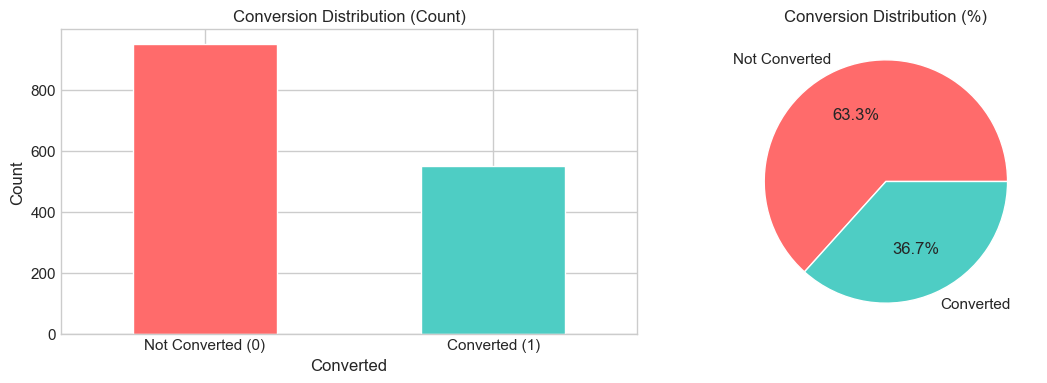

In [60]:
conversion_rate = df['converted'].mean() * 100
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
colors = ['#ff6b6b', '#4ecdc4']
df['converted'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Conversion Distribution (Count)')
axes[0].set_xlabel('Converted')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Converted (0)', 'Converted (1)'], rotation=0)

# Pie chart
df['converted'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors,
                                     labels=['Not Converted', 'Converted'])
axes[1].set_title('Conversion Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap (Numeric Features)

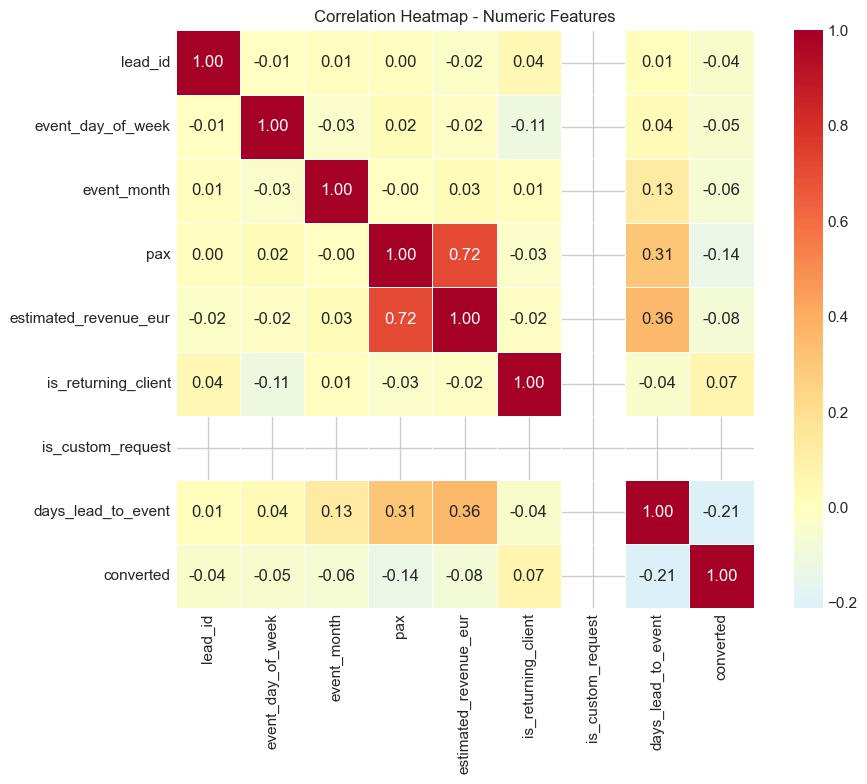


Correlation with 'converted':
converted                1.000000
is_returning_client      0.069241
lead_id                 -0.038981
event_day_of_week       -0.047873
event_month             -0.064955
estimated_revenue_eur   -0.076278
pax                     -0.139651
days_lead_to_event      -0.211565
is_custom_request             NaN
Name: converted, dtype: float64


In [61]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Correlation matrix
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

# Show correlations with target
print("\nCorrelation with 'converted':")
print(corr_matrix['converted'].sort_values(ascending=False))

### 3.5 Categorical Distributions

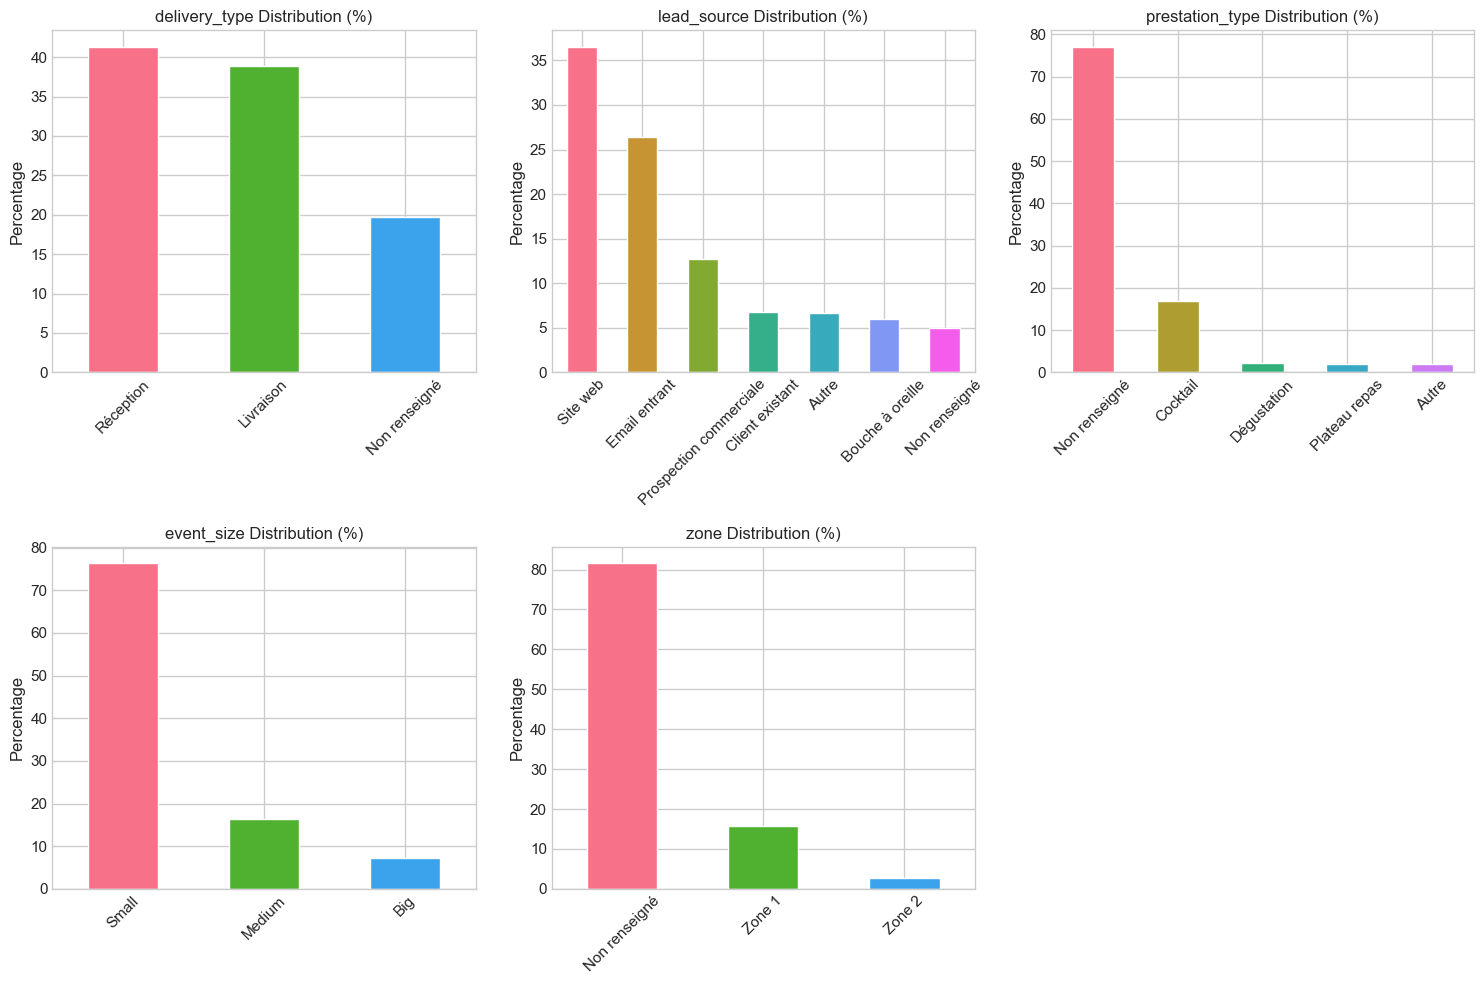

In [87]:
categorical_cols = ['delivery_type', 'lead_source', 'prestation_type', 'event_size', 'zone']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Compute percentages
    percentages = df[col].value_counts(normalize=True) * 100
    percentages.plot(kind='bar', ax=axes[i], color=sns.color_palette('husl', n_colors=len(df[col].unique())))
    
    axes[i].set_title(f'{col} Distribution (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage')
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

---
## 4. Business Questions Analysis

### 4.1 Lead Sources Analysis
**Question:** what is the distribution of leads per year?

/tmp/ipykernel_33009/1968780935.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='event_year', data=df, palette='husl', order=sorted(df['event_year'].dropna().unique()))


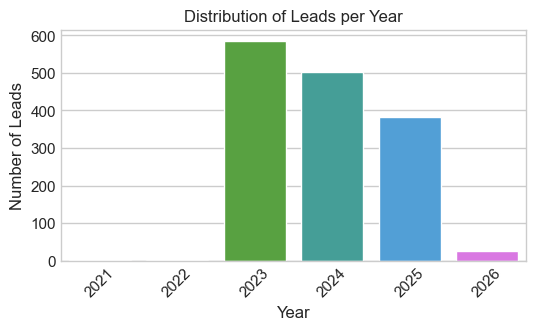

In [106]:
df['event_year'] = df['event_date'].dt.year

# Plot distribution of leads per year
plt.figure(figsize=(6,3))
sns.countplot(x='event_year', data=df, palette='husl', order=sorted(df['event_year'].dropna().unique()))
plt.title('Distribution of Leads per Year')
plt.xlabel('Year')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)
plt.show()


**Question:** From where are we getting most leads? How many were converted by source type?

LEAD SOURCE ANALYSIS
            lead_source  total_leads  converted_leads  conversion_rate
               Site web          548              130            23.72
          Email entrant          396              166            41.92
Prospection commerciale          190              103            54.21
        Client existant          102               50            49.02
                  Autre          100               27            27.00
       Bouche à oreille           89               27            30.34
          Non renseigné           75               47            62.67


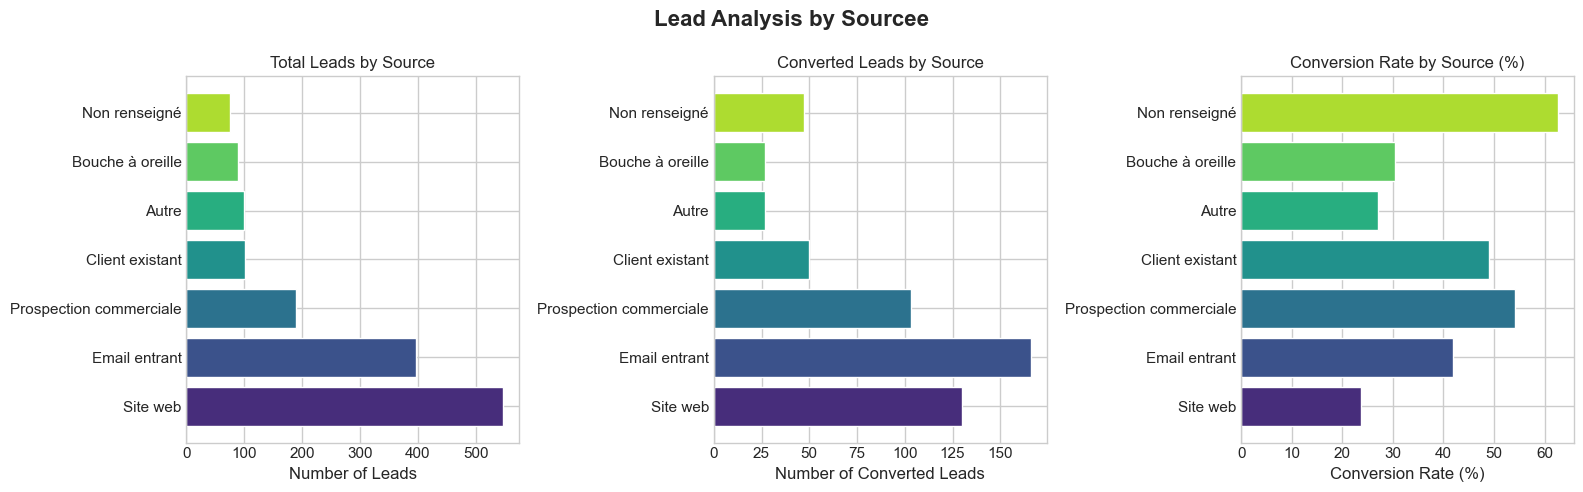

In [110]:
# Lead count and conversion by source
source_analysis = df.groupby('lead_source').agg(
    total_leads=('lead_id', 'count'),
    converted_leads=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()

source_analysis['conversion_rate'] = (source_analysis['conversion_rate'] * 100).round(2)
source_analysis = source_analysis.sort_values('total_leads', ascending=False)

print("=" * 60)
print("LEAD SOURCE ANALYSIS")
print("=" * 60)
print(source_analysis.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total leads by source
colors = sns.color_palette('viridis', n_colors=len(source_analysis))
axes[0].barh(source_analysis['lead_source'], source_analysis['total_leads'], color=colors)
axes[0].set_title('Total Leads by Source')
axes[0].set_xlabel('Number of Leads')

# Converted leads by source
axes[1].barh(source_analysis['lead_source'], source_analysis['converted_leads'], color=colors)
axes[1].set_title('Converted Leads by Source')
axes[1].set_xlabel('Number of Converted Leads')

# Conversion rate by source
axes[2].barh(source_analysis['lead_source'], source_analysis['conversion_rate'], color=colors)
axes[2].set_title('Conversion Rate by Source (%)')
axes[2].set_xlabel('Conversion Rate (%)')

fig.suptitle('Lead Analysis by Sourcee', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [64]:
data['lead_source'].value_counts()

lead_source
Site web                   548
Email entrant              396
Prospection commerciale    190
Client existant            102
Autre                      100
Bouche à oreille            89
Non renseigné               75
Name: count, dtype: int64

### 4.2 Prestation Type Analysis
**Question:** What type of prestation converts the most? What is its delivery type? Is it a custom request?

LEAD SOURCE ANALYSIS
prestation_type  total_leads  converted_leads  conversion_rate
  Non renseigné         1156              404            34.95
       Cocktail          253               89            35.18
    Dégustation           35               35           100.00
          Autre           28               10            35.71
  Plateau repas           28               12            42.86


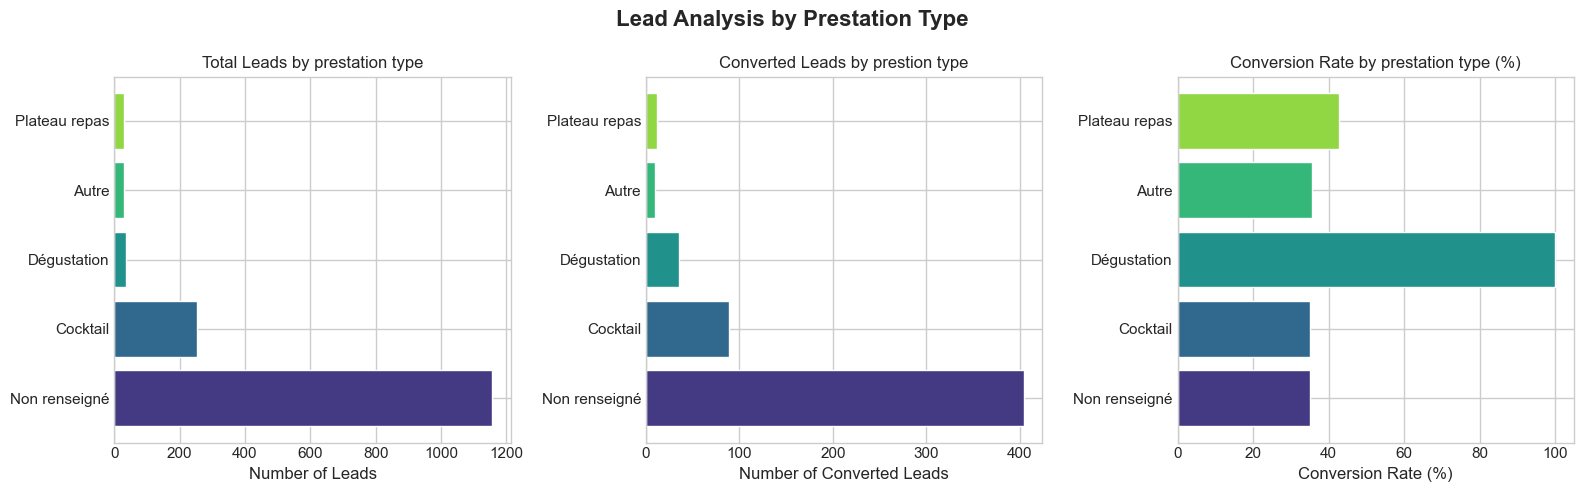

In [109]:
# Lead count and conversion by source
source_analysis = df.groupby('prestation_type').agg(
    total_leads=('lead_id', 'count'),
    converted_leads=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()

source_analysis['conversion_rate'] = (source_analysis['conversion_rate'] * 100).round(2)
source_analysis = source_analysis.sort_values('total_leads', ascending=False)

print("=" * 60)
print("LEAD SOURCE ANALYSIS")
print("=" * 60)
print(source_analysis.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total leads by source
colors = sns.color_palette('viridis', n_colors=len(source_analysis))
axes[0].barh(source_analysis['prestation_type'], source_analysis['total_leads'], color=colors)
axes[0].set_title('Total Leads by prestation type')
axes[0].set_xlabel('Number of Leads')

# Converted leads by source
axes[1].barh(source_analysis['prestation_type'], source_analysis['converted_leads'], color=colors)
axes[1].set_title('Converted Leads by prestion type')
axes[1].set_xlabel('Number of Converted Leads')

# Conversion rate by source
axes[2].barh(source_analysis['prestation_type'], source_analysis['conversion_rate'], color=colors)
axes[2].set_title('Conversion Rate by prestation type (%)')
axes[2].set_xlabel('Conversion Rate (%)')

fig.suptitle('Lead Analysis by Prestation Type', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

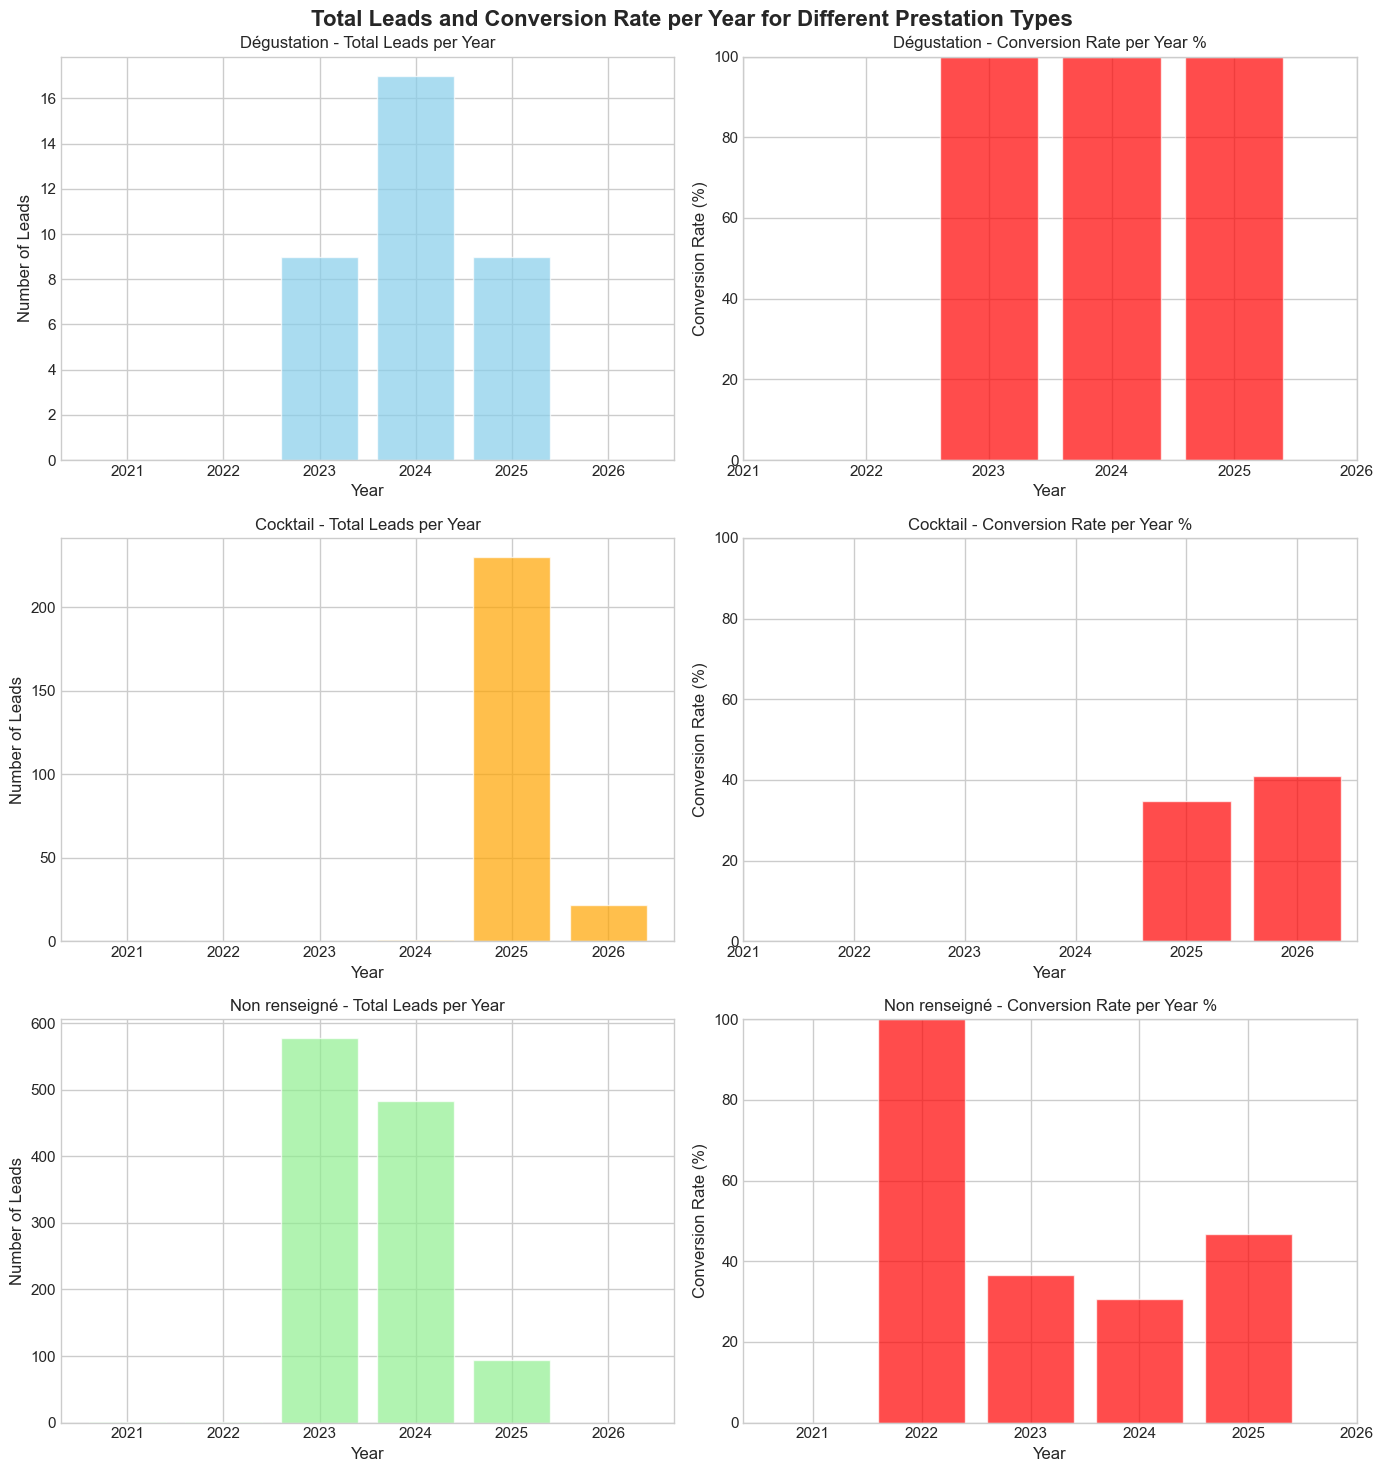

In [140]:
types_of_interest = ['Dégustation', 'Cocktail', 'Non renseigné']
colors = ['skyblue', 'orange', 'lightgreen']

fig, axes = plt.subplots(len(types_of_interest), 2, figsize=(14, 5*len(types_of_interest)))

if len(types_of_interest) == 1:
    axes = [axes]

all_years = sorted(df['event_year'].dropna().unique())

for i, prestation in enumerate(types_of_interest):
    df_type = df[df['prestation_type'] == prestation]
    
    # Total leads per year
    leads_per_year = df_type['event_year'].value_counts().reindex(all_years, fill_value=0).sort_index()
    
    # Conversion per year — filter BEFORE grouping
    df_type_with_leads = df_type[df_type['event_year'].isin(leads_per_year[leads_per_year > 0].index)]
    
    if len(df_type_with_leads) > 0:
        conversion_per_year = df_type_with_leads.groupby('event_year')['converted'].mean() * 100
    else:
        conversion_per_year = pd.Series(dtype=float)
    
    # Left plot: total leads
    ax1 = axes[i][0]
    ax1.bar(leads_per_year.index, leads_per_year.values, color=colors[i], alpha=0.7)
    ax1.set_title(f'{prestation} - Total Leads per Year')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Number of Leads')
    ax1.set_xticks(all_years)
    
    # Right plot: conversion %
    ax2 = axes[i][1]
    if len(conversion_per_year) > 0:
        ax2.bar(conversion_per_year.index, conversion_per_year.values, color='red', alpha=0.7)
    ax2.set_title(f'{prestation} - Conversion Rate per Year %')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Conversion Rate (%)')
    ax2.set_ylim(0, 100)
    ax2.set_xticks(all_years)

fig.suptitle('Total Leads and Conversion Rate per Year for Different Prestation Types', fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

In [65]:
print("=" * 60)
print("PRESTATION TYPE ANALYSIS")
print("=" * 60)

# Analysis by conversion status
prestation_analysis = df.groupby(['prestation_type', 'converted']).agg(
    count=('lead_id', 'count')
).reset_index()

# Pivot for clear view
prestation_pivot = prestation_analysis.pivot(index='prestation_type', columns='converted', values='count').fillna(0)
prestation_pivot.columns = ['Not Converted', 'Converted']
prestation_pivot['Total'] = prestation_pivot['Not Converted'] + prestation_pivot['Converted']
prestation_pivot['Conversion Rate (%)'] = (prestation_pivot['Converted'] / prestation_pivot['Total'] * 100).round(2)
prestation_pivot = prestation_pivot.sort_values('Conversion Rate (%)', ascending=False)

print("\n--- Prestation Type Performance ---")
print(prestation_pivot.to_string())

PRESTATION TYPE ANALYSIS

--- Prestation Type Performance ---
                 Not Converted  Converted   Total  Conversion Rate (%)
prestation_type                                                       
Dégustation                0.0       35.0    35.0               100.00
Plateau repas             16.0       12.0    28.0                42.86
Autre                     18.0       10.0    28.0                35.71
Cocktail                 164.0       89.0   253.0                35.18
Non renseigné            752.0      404.0  1156.0                34.95


In [66]:
# Delivery type analysis for converted vs non-converted
print("\n--- Delivery Type by Conversion Status ---")

delivery_analysis = df.groupby(['delivery_type', 'converted']).size().unstack(fill_value=0)
delivery_analysis.columns = ['Not Converted', 'Converted']
delivery_analysis['Total'] = delivery_analysis['Not Converted'] + delivery_analysis['Converted']
delivery_analysis['Conversion Rate (%)'] = (delivery_analysis['Converted'] / delivery_analysis['Total'] * 100).round(2)
delivery_analysis = delivery_analysis.sort_values('Conversion Rate (%)', ascending=False)

print(delivery_analysis.to_string())


--- Delivery Type by Conversion Status ---
               Not Converted  Converted  Total  Conversion Rate (%)
delivery_type                                                      
Livraison                302        282    584                48.29
Réception                387        233    620                37.58
Non renseigné            261         35    296                11.82


In [67]:
# Custom request analysis
print("\n--- Custom Request by Conversion Status ---")
custom_analysis = df.groupby(['is_custom_request', 'converted']).size().unstack(fill_value=0)
custom_analysis.columns = ['Not Converted', 'Converted']
custom_analysis['Total'] = custom_analysis['Not Converted'] + custom_analysis['Converted']
custom_analysis['Conversion Rate (%)'] = (custom_analysis['Converted'] / custom_analysis['Total'] * 100).round(2)

# Map index values instead of directly assigning
index_mapping = {0: 'Standard Request', 1: 'Custom Request'}
custom_analysis.index = custom_analysis.index.map(index_mapping)

print(custom_analysis.to_string())


--- Custom Request by Conversion Status ---
                   Not Converted  Converted  Total  Conversion Rate (%)
is_custom_request                                                      
Standard Request             950        550   1500                36.67


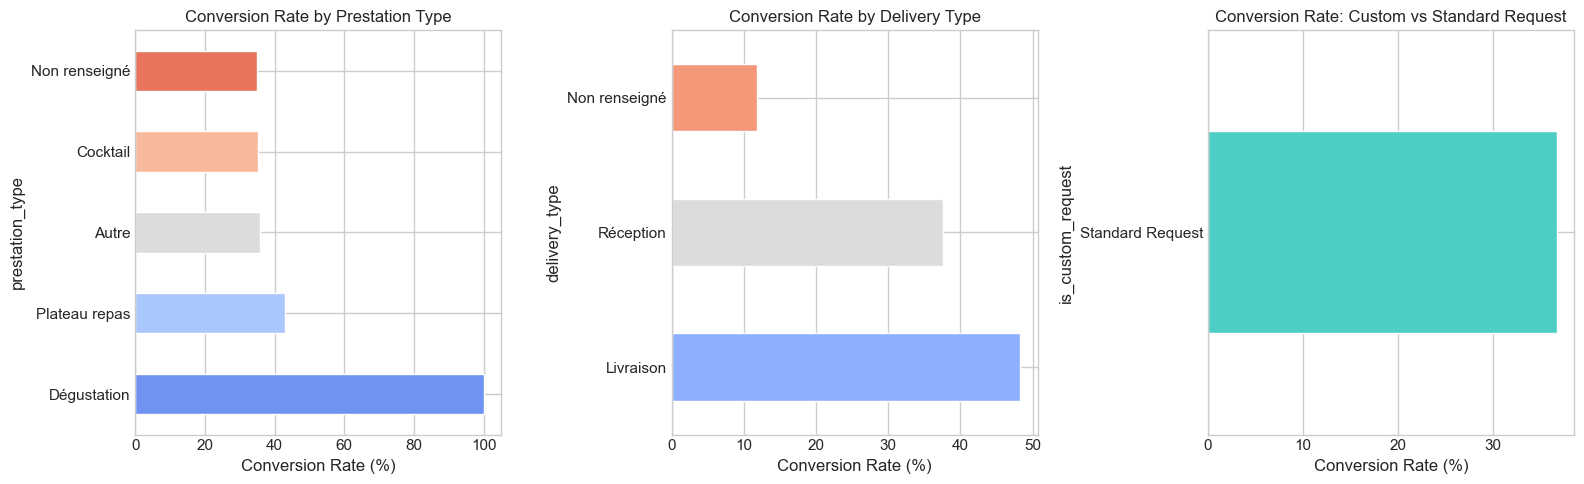

In [68]:
# Visualization for prestation analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Prestation type conversion rates
prestation_pivot['Conversion Rate (%)'].plot(kind='barh', ax=axes[0], color=sns.color_palette('coolwarm', n_colors=len(prestation_pivot)))
axes[0].set_title('Conversion Rate by Prestation Type')
axes[0].set_xlabel('Conversion Rate (%)')

# Delivery type conversion rates
delivery_analysis['Conversion Rate (%)'].plot(kind='barh', ax=axes[1], color=sns.color_palette('coolwarm', n_colors=len(delivery_analysis)))
axes[1].set_title('Conversion Rate by Delivery Type')
axes[1].set_xlabel('Conversion Rate (%)')

# Custom request
custom_analysis['Conversion Rate (%)'].plot(kind='barh', ax=axes[2], color=['#4ecdc4', '#ff6b6b'])
axes[2].set_title('Conversion Rate: Custom vs Standard Request')
axes[2].set_xlabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

### 4.3 Seasonality Analysis
**Question:** Is there a relationship between event's month and conversion? (Season → Type → Converted)

In [69]:
# Add season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['event_month'].apply(get_season)

print("=" * 60)
print("SEASONALITY ANALYSIS")
print("=" * 60)

# Season analysis
season_analysis = df.groupby('season').agg(
    total_leads=('lead_id', 'count'),
    converted_leads=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()

season_analysis['conversion_rate'] = (season_analysis['conversion_rate'] * 100).round(2)

# Order seasons
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_analysis['season'] = pd.Categorical(season_analysis['season'], categories=season_order, ordered=True)
season_analysis = season_analysis.sort_values('season')

print("\n--- Conversion by Season ---")
print(season_analysis.to_string(index=False))

SEASONALITY ANALYSIS

--- Conversion by Season ---
season  total_leads  converted_leads  conversion_rate
Spring          358              141            39.39
Summer          315               97            30.79
Autumn          467              170            36.40
Winter          360              142            39.44


In [70]:
# Monthly analysis
month_analysis = df.groupby('event_month').agg(
    total_leads=('lead_id', 'count'),
    converted_leads=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()

month_analysis['conversion_rate'] = (month_analysis['conversion_rate'] * 100).round(2)

# Map month numbers to names
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
month_analysis['month_name'] = month_analysis['event_month'].map(month_names)

print("\n--- Conversion by Month ---")
print(month_analysis.to_string(index=False))


--- Conversion by Month ---
 event_month  total_leads  converted_leads  conversion_rate month_name
           1          108               43            39.81        Jan
           2           83               45            54.22        Feb
           3          157               63            40.13        Mar
           4          105               44            41.90        Apr
           5           96               34            35.42        May
           6          213               67            31.46        Jun
           7           82               26            31.71        Jul
           8           20                4            20.00        Aug
           9          165               58            35.15        Sep
          10          157               62            39.49        Oct
          11          145               50            34.48        Nov
          12          169               54            31.95        Dec


In [71]:
# Season x Prestation Type Analysis
print("\n--- Season x Prestation Type: Conversion Rate (%) ---")

season_prestation = df.groupby(['season', 'prestation_type']).agg(
    conversion_rate=('converted', 'mean')
).reset_index()

season_prestation['conversion_rate'] = (season_prestation['conversion_rate'] * 100).round(2)
season_prestation_pivot = season_prestation.pivot(index='prestation_type', columns='season', values='conversion_rate').fillna(0)

# Reorder columns
season_prestation_pivot = season_prestation_pivot[['Spring', 'Summer', 'Autumn', 'Winter']]

print(season_prestation_pivot.to_string())


--- Season x Prestation Type: Conversion Rate (%) ---
season           Spring  Summer  Autumn  Winter
prestation_type                                
Autre             33.33   20.00   62.50   22.22
Cocktail          38.89   31.58   36.90   32.76
Dégustation      100.00  100.00  100.00  100.00
Non renseigné     36.50   29.80   33.15   40.21
Plateau repas     14.29    0.00   70.00   50.00


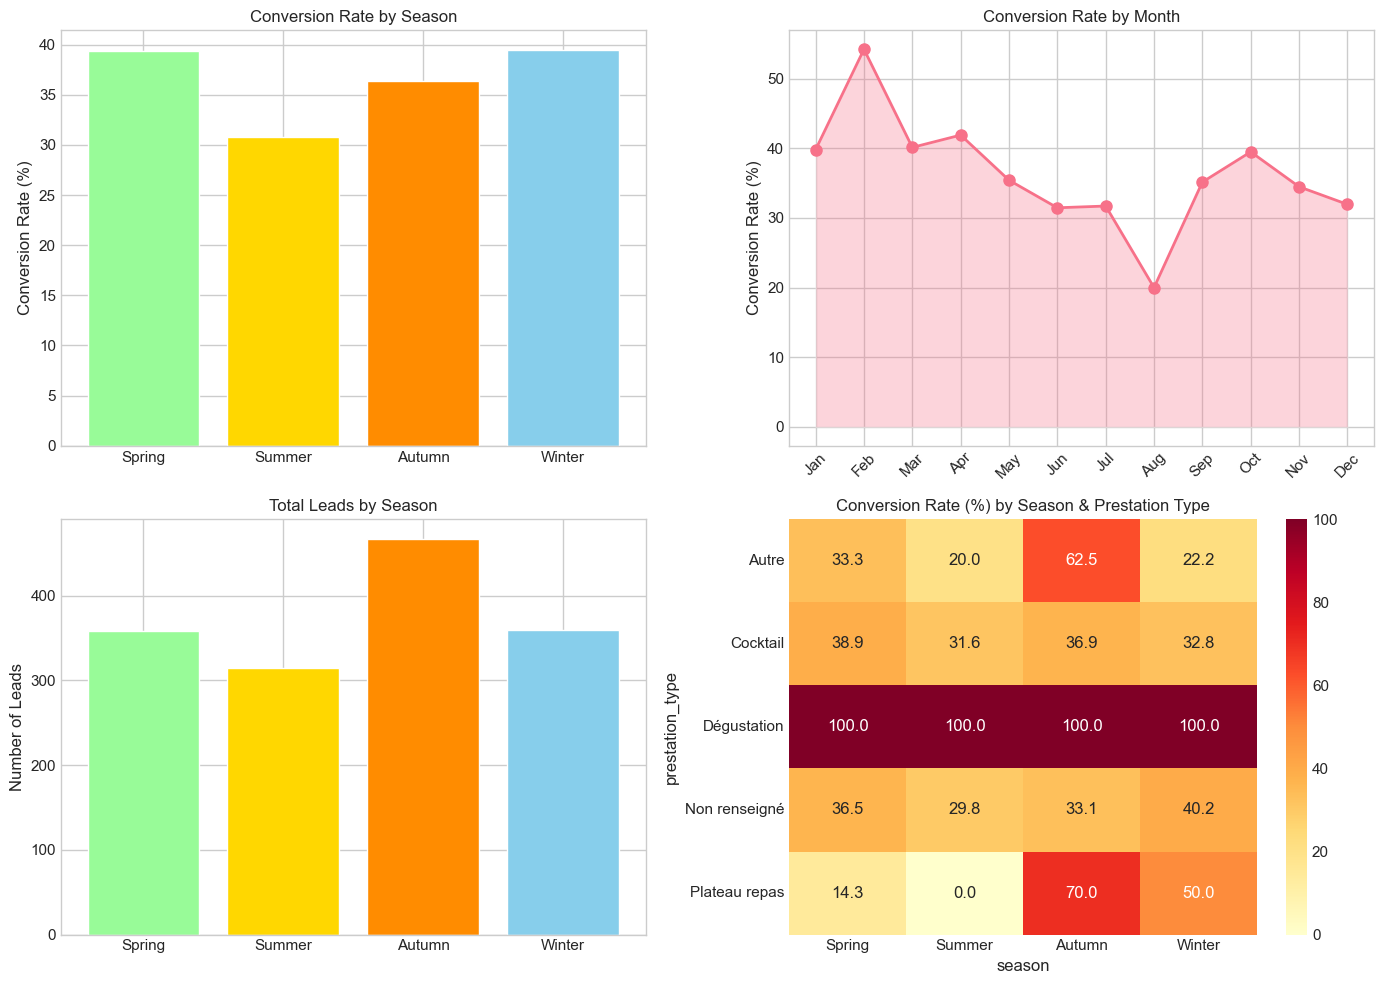

In [72]:
# Visualizations for seasonality
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Season conversion rate
season_colors = {'Spring': '#98fb98', 'Summer': '#ffd700', 'Autumn': '#ff8c00', 'Winter': '#87ceeb'}
colors = [season_colors[s] for s in season_analysis['season']]
axes[0, 0].bar(season_analysis['season'], season_analysis['conversion_rate'], color=colors)
axes[0, 0].set_title('Conversion Rate by Season')
axes[0, 0].set_ylabel('Conversion Rate (%)')

# Monthly conversion rate
axes[0, 1].plot(month_analysis['month_name'], month_analysis['conversion_rate'], marker='o', linewidth=2, markersize=8)
axes[0, 1].fill_between(month_analysis['month_name'], month_analysis['conversion_rate'], alpha=0.3)
axes[0, 1].set_title('Conversion Rate by Month')
axes[0, 1].set_ylabel('Conversion Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Total leads by season
axes[1, 0].bar(season_analysis['season'], season_analysis['total_leads'], color=colors)
axes[1, 0].set_title('Total Leads by Season')
axes[1, 0].set_ylabel('Number of Leads')

# Heatmap: Season x Prestation Type
sns.heatmap(season_prestation_pivot, annot=True, cmap='YlOrRd', fmt='.1f', ax=axes[1, 1])
axes[1, 1].set_title('Conversion Rate (%) by Season & Prestation Type')

plt.tight_layout()
plt.show()

# 5. XGboost Model

Feature engineering completed!
Dataset shape: (1500, 19)
Conversion rate: 36.67%

Missing values per feature:
pax                      0
estimated_revenue_eur    0
days_lead_to_event       0
event_year               0
event_month              0
revenue_per_pax          0
log_revenue              0
log_pax                  0
delivery_type            0
zone                     0
lead_source              0
prestation_type          0
event_size               0
event_day_of_week        0
season                   0
lead_time_category       0
is_returning_client      0
is_custom_request        0
is_weekend               0
dtype: int64

Features used: ['pax', 'estimated_revenue_eur', 'days_lead_to_event', 'event_year', 'event_month', 'revenue_per_pax', 'log_revenue', 'log_pax', 'delivery_type', 'zone', 'lead_source', 'prestation_type', 'event_size', 'event_day_of_week', 'season', 'lead_time_category', 'is_returning_client', 'is_custom_request', 'is_weekend']

Training set size: 1200
Test set s

/tmp/ipykernel_33009/3169020936.py:80: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X[col].fillna(X[col].median(), inplace=True)
/tmp/ipykernel_33009/3169020936.py:80: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to


MODEL PERFORMANCE

Accuracy: 69.33%
ROC AUC Score: 0.7962

Classification Report:
               precision    recall  f1-score   support

Not Converted       0.79      0.70      0.74       190
    Converted       0.57      0.68      0.62       110

     accuracy                           0.69       300
    macro avg       0.68      0.69      0.68       300
 weighted avg       0.71      0.69      0.70       300


Confusion Matrix:
[[133  57]
 [ 35  75]]

Detailed Metrics:
True Positives: 75
True Negatives: 133
False Positives: 57
False Negatives: 35
Precision: 0.5682
Recall: 0.6818
F1-Score: 0.6198


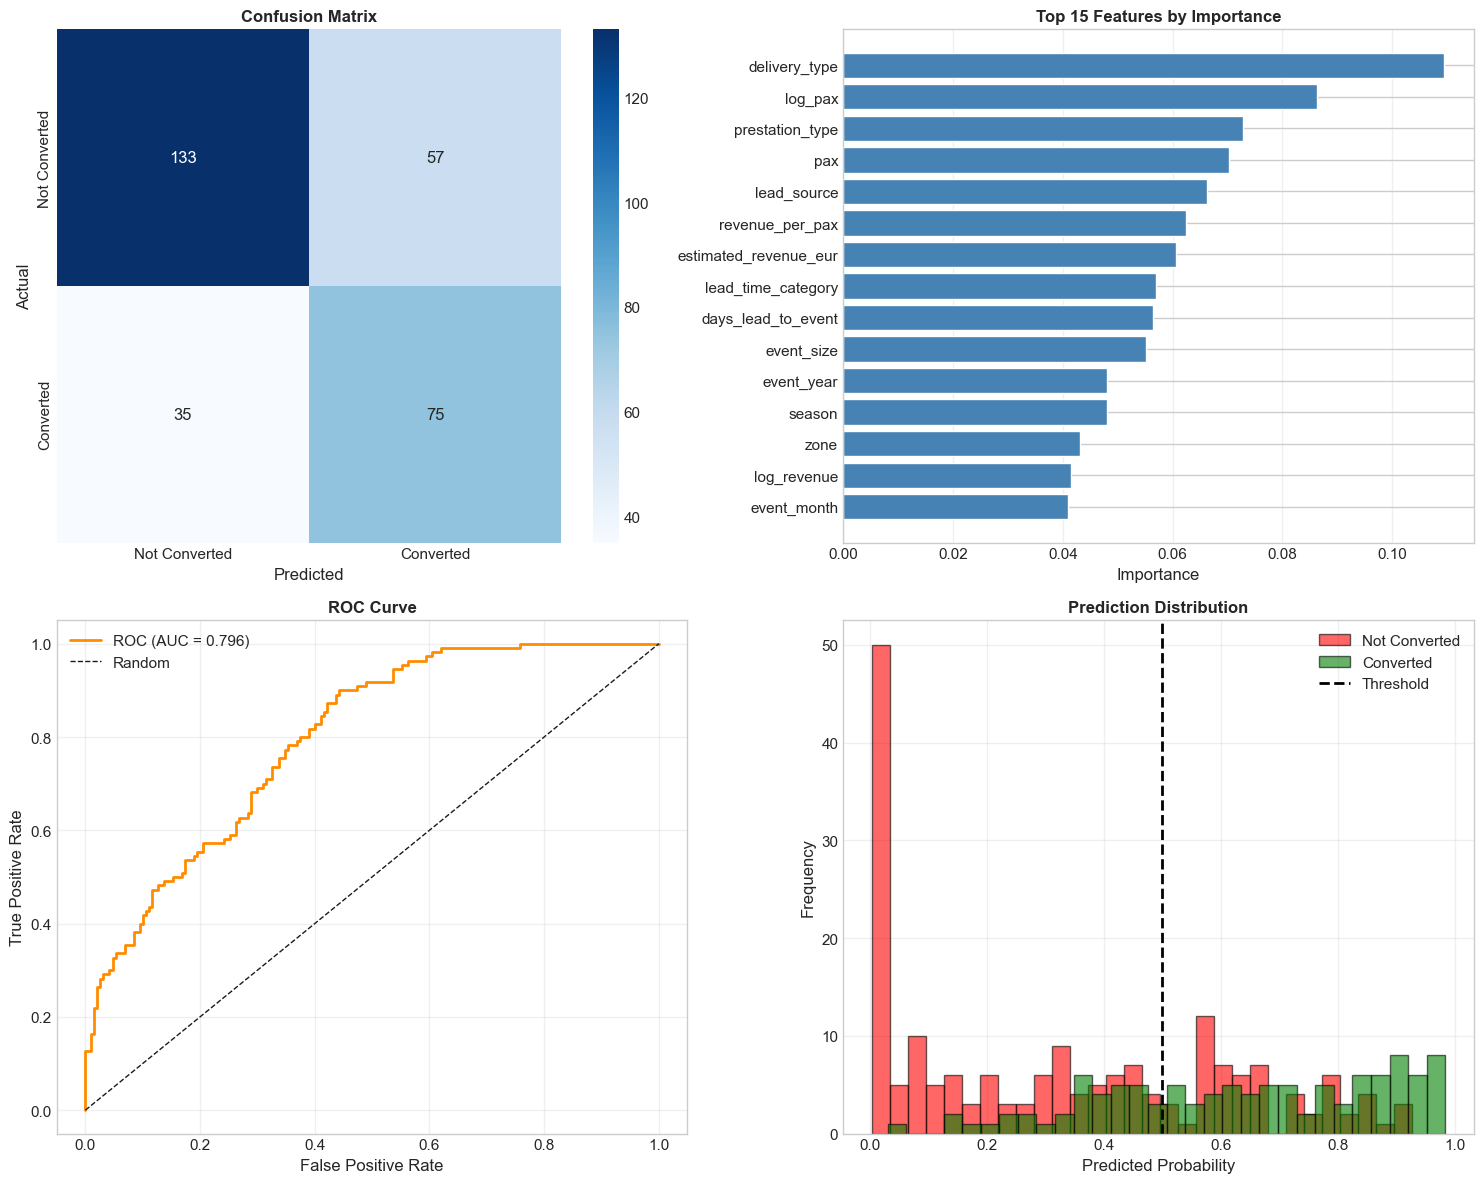


TOP 15 MOST IMPORTANT FEATURES
              feature  importance
        delivery_type    0.109420
              log_pax    0.086386
      prestation_type    0.072775
                  pax    0.070333
          lead_source    0.066204
      revenue_per_pax    0.062357
estimated_revenue_eur    0.060643
   lead_time_category    0.056954
   days_lead_to_event    0.056449
           event_size    0.055233
           event_year    0.048059
               season    0.048050
                 zone    0.043135
          log_revenue    0.041502
          event_month    0.040888

FEATURE IMPORTANCE BY CATEGORY

Top Numeric Features:
              feature  importance
              log_pax    0.086386
                  pax    0.070333
      revenue_per_pax    0.062357
estimated_revenue_eur    0.060643
   days_lead_to_event    0.056449

Top Categorical Features:
           feature  importance
     delivery_type    0.109420
   prestation_type    0.072775
       lead_source    0.066204
lead_time_cate

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import xgboost as xgb

# Create a copy of the dataframe for modeling
df_model = df.copy()

# Remove rows with missing target variable
df_model = df_model[df_model['converted'].notna()].copy()

# Additional feature engineering
# Revenue per person
df_model['revenue_per_pax'] = df_model['estimated_revenue_eur'] / df_model['pax'].replace(0, 1)

# Log transformations for skewed features
df_model['log_revenue'] = np.log1p(df_model['estimated_revenue_eur'])
df_model['log_pax'] = np.log1p(df_model['pax'])

# Is weekend event
df_model['is_weekend'] = df_model['event_day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Lead time categories
df_model['lead_time_category'] = pd.cut(
    df_model['days_lead_to_event'], 
    bins=[-np.inf, 7, 30, 90, np.inf],
    labels=['Last_minute', 'Short', 'Medium', 'Long']
)

print("Feature engineering completed!")

# Select features for the model
numeric_features = [
    'pax',
    'estimated_revenue_eur',
    'days_lead_to_event',
    'event_year',
    'event_month',
    'revenue_per_pax',
    'log_revenue',
    'log_pax'
]

categorical_features = [
    'delivery_type',
    'zone',
    'lead_source',
    'prestation_type',
    'event_size',
    'event_day_of_week',
    'season',
    'lead_time_category'
]

boolean_features = [
    'is_returning_client',
    'is_custom_request',
    'is_weekend'
]

all_features = numeric_features + categorical_features + boolean_features

# Create feature dataframe
X = df_model[all_features].copy()
y = df_model['converted'].copy()

print(f"Dataset shape: {X.shape}")
print(f"Conversion rate: {y.mean()*100:.2f}%")
print(f"\nMissing values per feature:")
print(X.isnull().sum())

# Handle missing values
# Fill numeric columns with median
for col in numeric_features:
    if col in X.columns:
        X[col].fillna(X[col].median(), inplace=True)

# Fill categorical columns with 'Unknown'
for col in categorical_features:
    if col in X.columns:
        X[col].fillna('Unknown', inplace=True)

# Fill boolean columns with False (0)
for col in boolean_features:
    if col in X.columns:
        X[col].fillna(0, inplace=True)

# Encode categorical variables
label_encoders = {}
for col in categorical_features:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

# Convert boolean columns to int
for col in boolean_features:
    if col in X.columns:
        X[col] = X[col].astype(int)

print(f"\nFeatures used: {list(X.columns)}")

# Split data BEFORE scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training conversion rate: {y_train.mean()*100:.2f}%")
print(f"Test conversion rate: {y_test.mean()*100:.2f}%")

# Apply feature scaling to numeric features only
scaler = StandardScaler()

# Fit scaler on training data only
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("\nFeature scaling applied!")
print(f"\nScaled features statistics (training set):")
print(X_train_scaled[numeric_features].describe())

# Train XGBoost model with scaled features
print("\nTraining XGBoost model with scaled features...")

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
)

# Train with early stopping
eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]
model.fit(
    X_train_scaled, 
    y_train,
    eval_set=eval_set,
    verbose=False
)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate model
print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Converted', 'Converted']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nDetailed Metrics:")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_xticklabels(['Not Converted', 'Converted'])
axes[0, 0].set_yticklabels(['Not Converted', 'Converted'])

# 2. Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 15
axes[0, 1].barh(range(top_n), feature_importance['importance'].head(top_n), color='steelblue')
axes[0, 1].set_yticks(range(top_n))
axes[0, 1].set_yticklabels(feature_importance['feature'].head(top_n))
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title(f'Top {top_n} Features by Importance', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1, 0].plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})', color='darkorange')
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Prediction Distribution
axes[1, 1].hist(y_pred_proba[y_test==0], bins=30, alpha=0.6, label='Not Converted', color='red', edgecolor='black')
axes[1, 1].hist(y_pred_proba[y_test==1], bins=30, alpha=0.6, label='Converted', color='green', edgecolor='black')
axes[1, 1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Prediction Distribution', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print top features
print("\n" + "="*60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*60)
print(feature_importance.head(15).to_string(index=False))

# Feature importance by category
print("\n" + "="*60)
print("FEATURE IMPORTANCE BY CATEGORY")
print("="*60)

numeric_importance = feature_importance[feature_importance['feature'].isin(numeric_features)]
categorical_importance = feature_importance[feature_importance['feature'].isin(categorical_features)]
boolean_importance = feature_importance[feature_importance['feature'].isin(boolean_features)]

print("\nTop Numeric Features:")
print(numeric_importance.head(5).to_string(index=False))

print("\nTop Categorical Features:")
print(categorical_importance.head(5).to_string(index=False))

print("\nBoolean Features:")
print(boolean_importance.to_string(index=False))

print("\n" + "="*60)
print("MODEL TRAINING COMPLETED!")
print("="*60)

# 6. Summary & Key Insights

### Lead Sources
- Websites and emails generate the largest portion of leads, around **60%**.  
- Among these leads, the most common service type is **Unspecified (Non renseigné)**.  
- Leads from **Non renseigné**, **Prospection Commerciale**, and **Existing Clients** have better conversion rates compared to website and email leads.

### Event Size
- Most leads are for **small events (75%)**, while medium and large events make up **12% and 8%**, respectively.

### Service Type
- **Cocktail, Dégustation, and Unspecified services** convert well, even if the number of leads for some of them is small.  
- The top three service types by number of conversions are: **Non renseigné, Cocktail, Dégustation**.

### Delivery Type
- The order by highest number of conversions by delivery type is: **Livraison**, **Réception**, and **Non renseigné**.

### Seasonality
- **Winter** has the highest conversion rate, around **40%**, with **Plateau repas** being the most requested service.  
- **Autumn and Spring** come next, mainly with Plateau and Non renseigné services.  
- **Summer** sees the lowest conversion.  
- **February** is the peak month for conversions, while **August** is the slowest.

### Key Features Driving Conversion
- From my percpective and from doing the EDA,Leads with **engagement through prospection or existing client relationships**, requests for **Cocktail, Dégustation, or Plateau repas services**, **small to medium events**, and inquiries in **winter or February** are the ones that maximize conversion rates.


# 7. Business Questions

## Remarque on Your Social Media 


To better understand the company's marketing performance, I conducted a review of their social media presence:

- **Instagram:** 18.6k followers  
- **TikTok:** 3k followers  
- **Facebook:** 13k followers  

While most posts receive relatively low engagement, with typical views **not exceeding 7k**, there was a notable exception: one post reached **3 million views**, driven by a collaboration with a well-known influencer.  



### 1. Data Limitations
1. The biggest limitation was the lack of **client data**, which is crucial for business segmentation and understanding customer behavior.  

2. Leads with **Non renseigné** service type are all non-converted, and the same goes for **Non renseigné** delivery type. Having this information would have helped to analyze which types to focus on or deprioritize.  

3. The **type of food served** could provide additional insights. While the prestation/service type is available, knowing the actual food details may help define specialties and guide development.  

4. The **exact location of the event** is missing, which would be useful for targeting advertising and identifying high-potential areas( I found out on your social media that you are based in paris and marseille I thought the coustumer would orgenize events somewhere else for events of reception type) 


### 2. Deployment
1. In first place, the score would help to focus on the high probabel targets which are closer to converte that others, in addition it may help the commerciale team to adjust the offer to try increase the chances of conversion of the lead by meeting the customer's need and expectations. A workflow my be like :
        - Get the leads score from the model and make priority on high probabel ones.
        - Proceed with the chosen ones trying to secure a conversion.
        - update the database with the new interaction.

2. KPIs : - Totale real conversion rate vs the predicted one.
 - Increase rate in the targeted segments to decide whether acctually our plan works as expected.
 - The time needed for a lead to be converted to decide are we convinient enough for custumers or we need to work more on our commercials. 

3. Question from the next part is part of the answer as if the compercial team decides to focus on a specific class with high or low conversion rate would be the most risquky thing to do, As I sugest keeping up with the usual way of doing business while trying the new approach on small segments of leads, using the model to predict whether the leads that does not fall under the trial part and compare the prediction with the reality may be a good start to decide how much to rely on the model.




### 3. Buisness Objectives 
1. Yes, an objective of reaching conversion rate of 45% in 6 months is realistic, simply because 35% is not the limit of such company.

2. The first thing first that I would like to act on is to help marketing team do accurate analysis about their customers and the market in general and building a good segmentation model because what I have noticed is that they are missing information about what to target and how, as the company's social media numbers are very low compared to the 8 long years of existence, in addition to the lack of a logical and clear target audience from the analysis I have done.

3. As the yearly totale leads of the company were in continious shrink, getting good results during the internship periode may not totaly reflect on the intern's role but he would definitely have a hand on it (3rd newton's law : action and reaction).


### 4. Critical Reflection
I totally desagree with his statement because we deploy the model to get an idea about the conversion rate which is in any case not sure so a lead with 90% conversion rate would be my priority to contact and relance as we increase the probability by action not by assumption, in the case where I insure it I will proceed with less probable leads.
